# Ice Core Power Spectra
## Applications of spectral analysis techniques to synthetic data sets to assess how sampling methods, data handling, and statistical choices affect interpretability of ice core data sets in the frequency domain
<br/>
Originally coded by Rhys-Jasper León <br/>
Last updated 2026 April 09

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.fft import fft, fftfreq
from utils import *

## STEP 1: Create Data

Text(0, 0.5, 'Depth (m)')

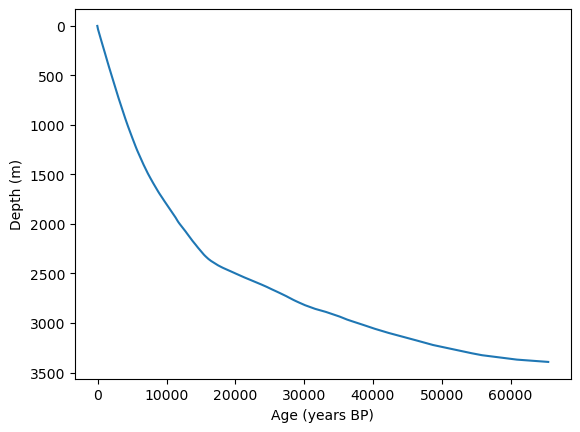

In [2]:
# read in WDC depth-age scale
wdc_data = pd.read_csv('WD2014_Chronology.tab', sep='\t', header=52)
wdc_depth = wdc_data['Depth ice/snow [m]']
wdc_age = wdc_data['Cal age [ka BP] (ice age)'] # part of the issue is that this chronology is already on even-time
wdc_age = wdc_age * 1000  # convert to years BP

# wdc_data.head()
plt.plot(wdc_age, wdc_depth)
plt.gca().invert_yaxis()
plt.xlabel('Age (years BP)')
plt.ylabel('Depth (m)')

Text(0.5, 0, 'Time (years)')

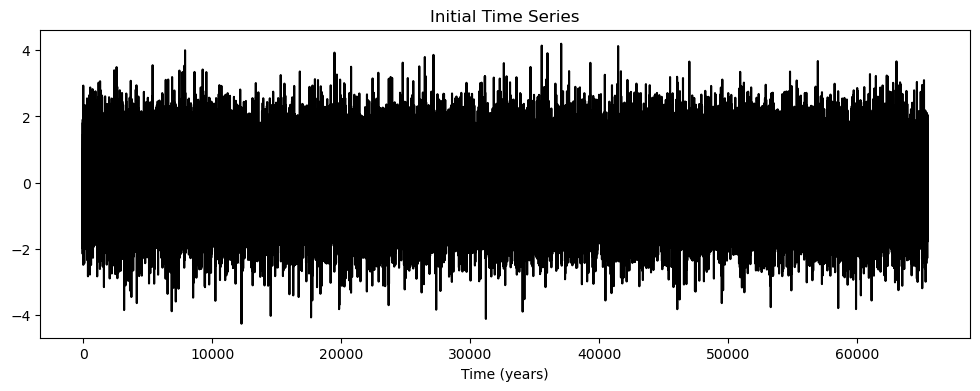

In [3]:
# specify length of time series (make sure it matches time length of wdc age model)
xlen = int(wdc_age.max())  # length of time series (years)

# create even time axis
x = np.arange(int(wdc_age.min()), xlen + 1)  # time (yr)
# create random noise
y = np.random.normal(0, 1, len(x)) # normal distibution, mean 0, std 1

# plot initial time series
fig, ax = plt.subplots(figsize=(12, 4))
plt.plot(x, y, label='Raw Synthetic Data', color='black')
plt.title('Initial Time Series')
# plt.xlim(0, 200)  # limit x-axis for better visibility
plt.xlabel('Time (years)')

## STEP 2: Compare fft vs. Welch
note about the fft: I took only the positive frequencies, which is done with `[:len(x)//2]`

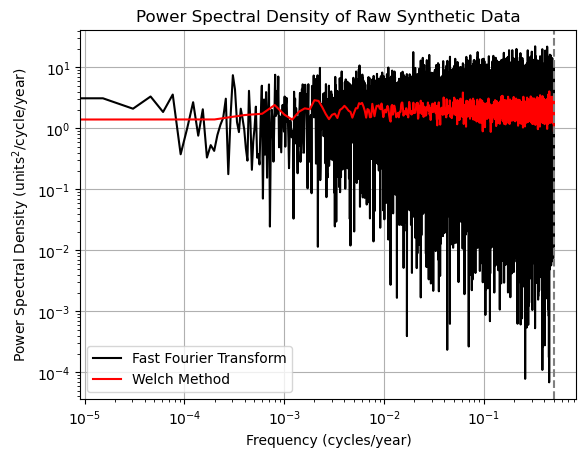

In [4]:
res = np.mean(np.diff(x))
fs = 1 / res  # sampling frequency (samples/yr)

freqw, psdw = welch(y, fs=fs, nperseg=5000) # frequency units: cycles/yr, output value: psd
fourier = fft(y) # output value: amplitude
freqf = fftfreq(len(x), res)[:len(x)//2] # frequency units: cycles/yr
psdf = 2 * np.abs(fourier)**2 / (len(x) * fs) # convert amplitude to psd


plt.figure()
# plot fft of initial time series
plt.plot(freqf, psdf[:len(x)//2], label='Fast Fourier Transform', color='black')
# plot welch method initial time series
plt.loglog(freqw, psdw, label='Welch Method', color='red')
plt.axvline(x=1/res/2, color='gray', linestyle='--', label=f'')
plt.xlabel('Frequency (cycles/year)')
plt.ylabel(r'Power Spectral Density (units$^2$/cycle/year)')
plt.title('Power Spectral Density of Raw Synthetic Data')
plt.grid()
plt.legend()

## STEP 3: Sampling Methods

### Discrete Averaging

C:\Users\rice\AppData\Local\Temp\ipykernel_12536\590412368.py:18: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 131, using nperseg = 131
  freqw, psdw = welch(y_ds, fs=fs) # frequency units: cycles/yr, output value: psd


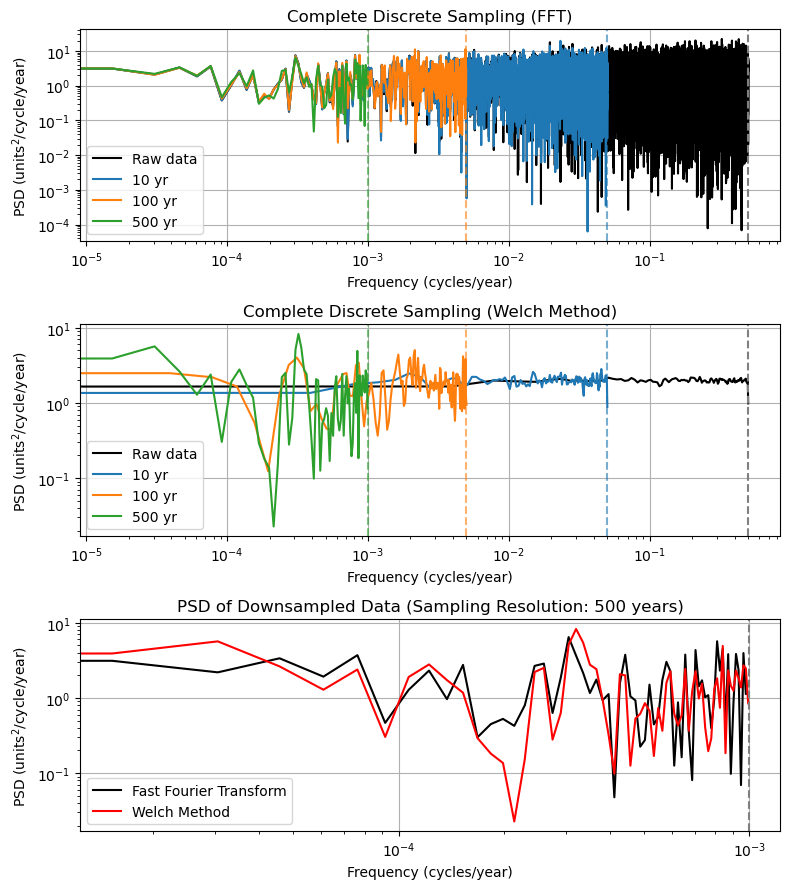

In [5]:
# complete discrete sampling
sampling_resolution = [10, 100, 500] # years

fig, ax = plt.subplots(3, 1, figsize=(8, 9))
fourier = fft(y) # output value: amplitude
freqf = fftfreq(len(x), 1)[:len(x)//2] # frequency units: cycles/yr
psdf = 2 * np.abs(fourier)**2 / (len(x) * 1) # convert amplitude to psd
ax[0].loglog(freqf, psdf[:len(x)//2], label='Raw data', color='black') # plot welch of raw data
ax[0].axvline(x=1/2, color='gray', linestyle='--', label=f'')
freqy, psdy = welch(y, fs=1)
ax[1].loglog(freqy, psdy, label='Raw data', color='black') # plot welch of raw data
ax[1].axvline(x=1/2, color='gray', linestyle='--', label=f'')

for i, res in enumerate(sampling_resolution):
    x_ds, y_ds = discrete_avg(x, y, res, method='full')
    fs = 1 / res  # sampling frequency (samples/yr)
    
    freqw, psdw = welch(y_ds, fs=fs) # frequency units: cycles/yr, output value: psd
    fourier = fft(y_ds) # output value: amplitude
    freqf = fftfreq(len(x_ds), res)[:len(x_ds)//2] # frequency units: cycles/yr
    psdf = 2 * np.abs(fourier)**2 / (len(x_ds) * fs) # convert amplitude to psd

    color = f'C{i}'

    # plot resulting spectra
    ax[0].loglog(freqf, psdf[:len(x_ds)//2], label=f'{res} yr', color=color) # plot fft
    ax[0].axvline(x=1/res/2, color=color, linestyle='--', alpha=0.6)
    ax[0].set_xlabel('Frequency (cycles/year)')
    ax[0].set_ylabel(r'PSD (units$^2$/cycle/year)')
    ax[0].set_title(f'Complete Discrete Sampling (FFT)')
    ax[0].grid()
    ax[0].legend()

    ax[1].loglog(freqw, psdw, label=f'{res} yr', color=color) # plot welch
    ax[1].axvline(x=1/res/2, color=color, linestyle='--', alpha=0.6)
    ax[1].set_xlabel('Frequency (cycles/year)')
    ax[1].set_ylabel(r'PSD (units$^2$/cycle/year)')
    ax[1].set_title(f'Complete Discrete Sampling (Welch Method)')
    ax[1].grid()
    ax[1].legend()

    if res == sampling_resolution[-1]:
        ax[2].plot(freqf, psdf[:len(x_ds)//2], label='Fast Fourier Transform', color='black') # plot fft
        ax[2].loglog(freqw, psdw, label='Welch Method', color='red') # plot welch
        ax[2].axvline(x=1/res/2, color='gray', linestyle='--', label=f'')
        ax[2].set_xlabel('Frequency (cycles/year)')
        ax[2].set_ylabel(r'PSD (units$^2$/cycle/year)')
        ax[2].set_title(f'PSD of Downsampled Data (Sampling Resolution: {res} years)')
        ax[2].grid()
        ax[2].legend()

plt.tight_layout()

C:\Users\rice\AppData\Local\Temp\ipykernel_12536\2135134458.py:20: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 131, using nperseg = 131
  freqw, psdw = welch(y_int, fs=fs) # frequency units: cycles/yr, output value: psd


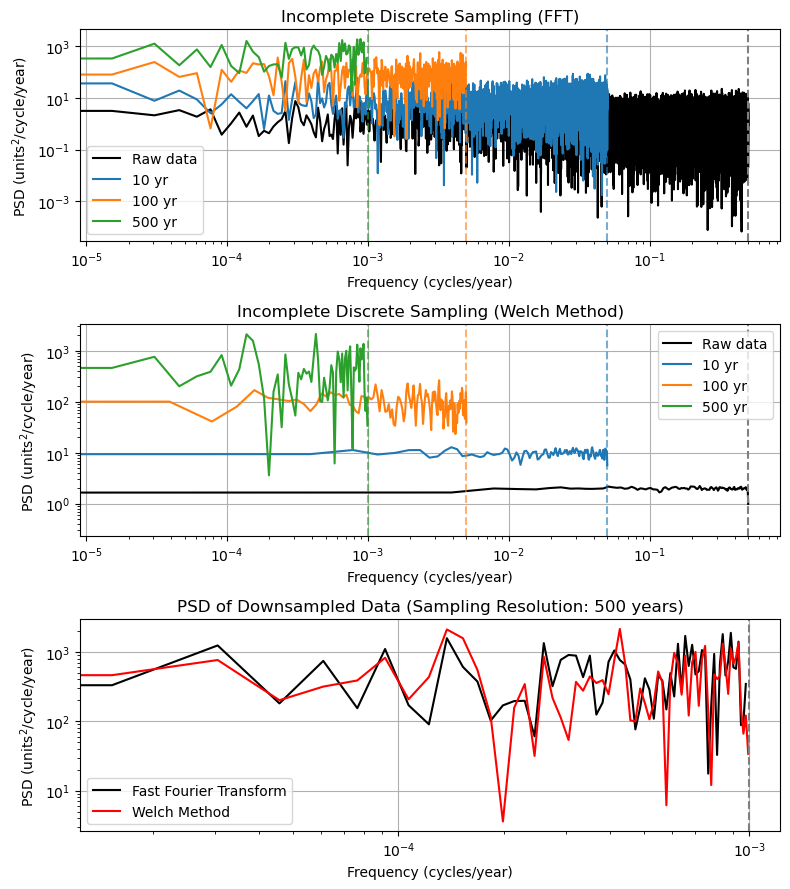

In [6]:
# incomplete discrete sampling (interpolation)
sampling_resolution = [10, 100, 500] # years

fig, ax = plt.subplots(3, 1, figsize=(8, 9))
fourier = fft(y) # output value: amplitude
freqf = fftfreq(len(x), 1)[:len(x)//2] # frequency units: cycles/yr
psdf = 2 * np.abs(fourier)**2 / (len(x) * 1) # convert amplitude to psd
ax[0].loglog(freqf, psdf[:len(x)//2], label='Raw data', color='black') # plot welch of raw data
ax[0].axvline(x=1/2, color='gray', linestyle='--', label=f'')
freqy, psdy = welch(y, fs=1)
ax[1].loglog(freqy, psdy, label='Raw data', color='black') # plot welch of raw data
ax[1].axvline(x=1/2, color='gray', linestyle='--', label=f'')


for i, res in enumerate(sampling_resolution):
    x_ds, y_ds = discrete_avg(x, y, res, method='full')
    y_int = np.interp(x_ds, x, y) # interpolate to downsample
    fs = 1 / res  # sampling frequency (samples/yr)
    
    freqw, psdw = welch(y_int, fs=fs) # frequency units: cycles/yr, output value: psd
    fourier = fft(y_int) # output value: amplitude
    freqf = fftfreq(len(x_ds), res)[:len(x_ds)//2] # frequency units: cycles/yr
    psdf = 2 * np.abs(fourier)**2 / (len(x_ds) * fs) # convert amplitude to psd

    color = f'C{i}'

    # plot resulting spectra
    ax[0].loglog(freqf, psdf[:len(x_ds)//2], label=f'{res} yr', color=color) # plot fft
    ax[0].axvline(x=1/res/2, color=color, linestyle='--', alpha=0.6)
    ax[0].set_xlabel('Frequency (cycles/year)')
    ax[0].set_ylabel(r'PSD (units$^2$/cycle/year)')
    ax[0].set_title(f'Incomplete Discrete Sampling (FFT)')
    ax[0].grid()
    ax[0].legend()

    ax[1].loglog(freqw, psdw, label=f'{res} yr', color=color) # plot welch
    ax[1].axvline(x=1/res/2, color=color, linestyle='--', alpha=0.6)
    ax[1].set_xlabel('Frequency (cycles/year)')
    ax[1].set_ylabel(r'PSD (units$^2$/cycle/year)')
    ax[1].set_title(f'Incomplete Discrete Sampling (Welch Method)')
    ax[1].grid()
    ax[1].legend()

    if res == sampling_resolution[-1]:
        ax[2].plot(freqf, psdf[:len(x_ds)//2], label='Fast Fourier Transform', color='black') # plot fft
        ax[2].loglog(freqw, psdw, label='Welch Method', color='red') # plot welch
        ax[2].axvline(x=1/res/2, color='gray', linestyle='--', label=f'')
        ax[2].set_xlabel('Frequency (cycles/year)')
        ax[2].set_ylabel(r'PSD (units$^2$/cycle/year)')
        ax[2].set_title(f'PSD of Downsampled Data (Sampling Resolution: {res} years)')
        ax[2].grid()
        ax[2].legend()

plt.tight_layout()

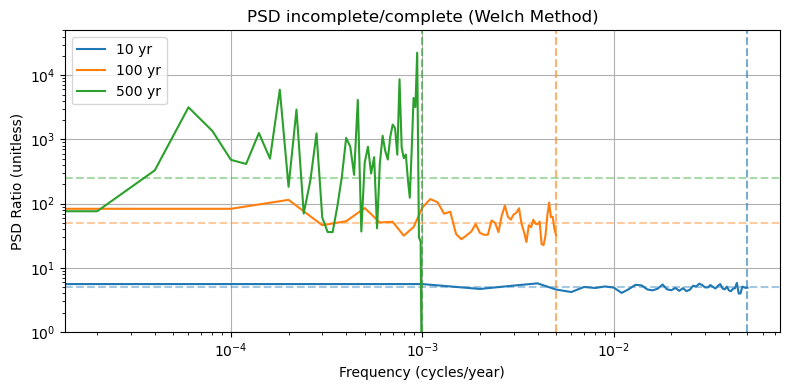

In [7]:
# compare complete vs incomplete discrete sampling
sampling_resolution = [10, 100, 500] # years

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

for i, res in enumerate(sampling_resolution):
    x_ds, y_ds = discrete_avg(x, y, res, method='full')
    y_int = np.interp(x_ds, x, y) # interpolate to downsample 
    fs = 1 / res  # sampling frequency (samples/yr)
    
    freqw, psdw = welch(y_ds, fs=fs, nperseg=100) # frequency units: cycles/yr, output value: psd
    fourier = fft(y_ds) # output value: amplitude
    freqf = fftfreq(len(x_ds), res)[:len(x_ds)//2] # frequency units: cycles/yr
    psdf = 2 * np.abs(fourier)**2 / (len(x_ds) * fs) # convert amplitude to psd

    freqwi, psdwi = welch(y_int, fs=fs, nperseg=100) # frequency units: cycles/yr, output value: psd
    fourieri = fft(y_int) # output value: amplitude
    freqfi = fftfreq(len(x_ds), res)[:len(x_ds)//2] # frequency units: cycles/yr
    psdfi = 2 * np.abs(fourieri)**2 / (len(x_ds) * fs) # convert amplitude to psd

    color = f'C{i}'

    # plot resulting spectra
    plt.loglog(freqw, psdwi/psdw, label=f'{res} yr', color=color) # plot welch ratio
    plt.axvline(x=fs/2, color=color, linestyle='--', alpha=0.6)
    plt.axhline(y=res/2, color=color, linestyle='--', alpha=0.4)  # reference line
    plt.xlabel('Frequency (cycles/year)')
    plt.ylabel('PSD Ratio (unitless)')
    plt.title(f'PSD incomplete/complete (Welch Method)')
    plt.grid()
    plt.legend()
    plt.ylim([1e0, 5e4]);

plt.tight_layout()

### Moving Averages

In [8]:
boxcar3 = boxcar(y, 3)
boxcar5 = boxcar(y, 5)
boxcar20 = boxcar(y, 21)
boxcar100 = boxcar(y, 101)

gaussian3 = gaussian(y, 3)
gaussian5 = gaussian(y, 5)
gaussian20 = gaussian(y, 21)
gaussian100 = gaussian(y, 101)

For Boxcar MA (5), 95% of own low-freq PSD reached at: 7.5294 yr
For Boxcar MA (20), 95% of own low-freq PSD reached at: 32.0000 yr
For Boxcar MA (100), 95% of own low-freq PSD reached at: 128.0000 yr


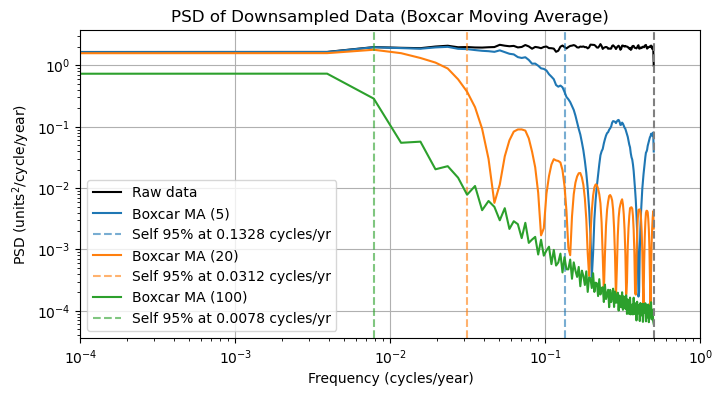

In [9]:
# boxcar moving average
fig, ax = plt.subplots(figsize=(8, 4))

freqy, psdy = welch(y, fs=1)
ax.loglog(freqy, psdy, label='Raw data', color='black') # plot welch of raw data

# produce spectra of smoothed data
for i, (data, label) in enumerate(zip([boxcar5, boxcar20, boxcar100], ['Boxcar MA (5)', 'Boxcar MA (20)', 'Boxcar MA (100)'])):
    res = np.mean(np.diff(x)) # downsampling resolution (years)
    fs = 1 / res  # sampling frequency (samples/yr)
    color = f'C{i}'

    freqw, psdw = welch(data, fs=fs) # frequency units: cycles/yr, output value: psd

    ax.loglog(freqw, psdw, color=color, label=label) # plot welch

    # find frequency where smoothed PSD is 95% of its own low-freq PSD
    freq_95_self = find_95_self(freqw, psdw)
    if freq_95_self:
        ax.axvline(freq_95_self, linestyle='--', color=color, alpha=0.6, label=f'Self 95% at {freq_95_self:.4f} cycles/yr')
        print(f'For {label}, 95% of own low-freq PSD reached at: {1/freq_95_self:.4f} yr')
    
ax.axvline(x=1/res/2, color='gray', linestyle='--', label=f'')
ax.set_xlabel('Frequency (cycles/year)')
ax.set_ylabel(r'PSD (units$^2$/cycle/year)')
ax.set_title(f'PSD of Downsampled Data (Boxcar Moving Average)')
ax.grid()
ax.legend()
ax.set_xlim(1e-4, 1e0);

For Gaussian MA (5), 95% of own low-freq PSD reached at: 4.0000 yr
For Gaussian MA (20), 95% of own low-freq PSD reached at: 17.0667 yr
For Gaussian MA (100), 95% of own low-freq PSD reached at: 85.3333 yr


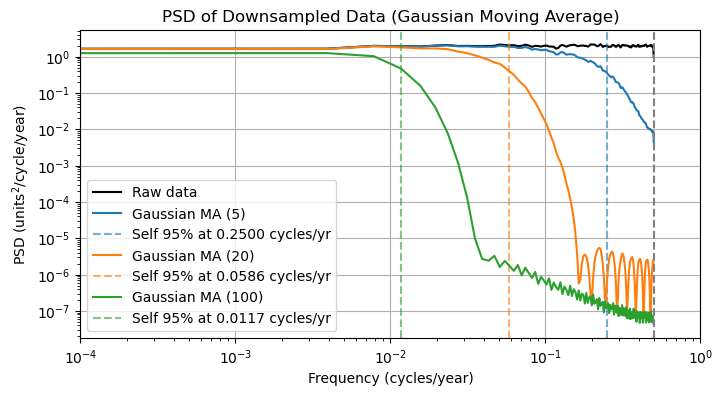

In [10]:
# gaussian moving average
fig, ax = plt.subplots(figsize=(8, 4))

freqy, psdy = welch(y, fs=1)
ax.loglog(freqy, psdy, label='Raw data', color='black') # plot welch of raw data

# produce spectra of smoothed data
for i, (data, label) in enumerate(zip([gaussian5, gaussian20, gaussian100], ['Gaussian MA (5)', 'Gaussian MA (20)', 'Gaussian MA (100)'])):
    res = np.mean(np.diff(x)) # downsampling resolution (years)
    fs = 1 / res  # sampling frequency (samples/yr)
    color = f'C{i}'

    freqw, psdw = welch(data, fs=fs) # frequency units: cycles/yr, output value: psd

    ax.loglog(freqw, psdw, color=color, label=label) # plot welch

    # find frequency where smoothed PSD is 95% of its own low-freq PSD
    freq_95_self = find_95_self(freqw, psdw)
    if freq_95_self:
        ax.axvline(freq_95_self, linestyle='--', color=color, alpha=0.6, label=f'Self 95% at {freq_95_self:.4f} cycles/yr')
        print(f'For {label}, 95% of own low-freq PSD reached at: {1/freq_95_self:.4f} yr')

ax.axvline(x=1/res/2, color='gray', linestyle='--', label=f'')
ax.set_xlabel('Frequency (cycles/year)')
ax.set_ylabel(r'PSD (units$^2$/cycle/year)')
ax.set_title(f'PSD of Downsampled Data (Gaussian Moving Average)')
ax.grid()
ax.legend()
ax.set_xlim(1e-4, 1e0);

## STEP 4: Depth-Age Relationship

In [11]:
dy = 0.5
wdc_even_depth = np.arange(int(wdc_depth.min()) + dy, wdc_depth.max(), dy) # cut off the ends to ensure no extrapolation
wdc_new_age = np.interp(wdc_even_depth, wdc_depth, wdc_age)
y_to_depth = np.interp(wdc_new_age, x, y) # data values connected to times on even depth scale (m)

Lowest resolution: 86.43333333331975 years
Average resolution: 9.648770050067222 years
Holocene average resolution: 2.970494019278743 years


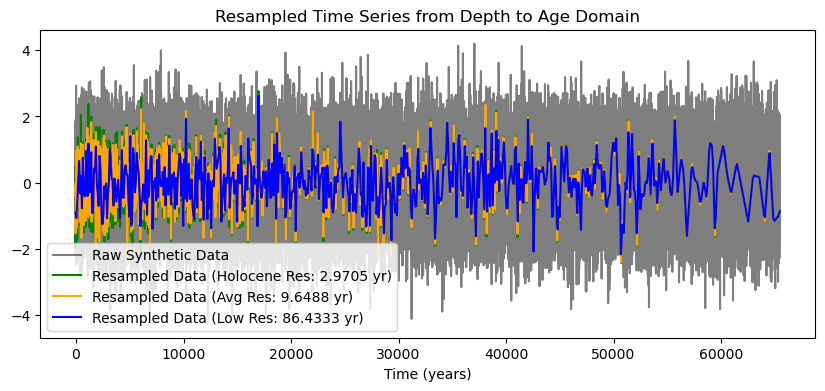

In [12]:
# low_res = np.max(np.diff(wdc_new_age))  # lowest resolution in years
low_res = np.diff(wdc_new_age)[-1]  # resolution between last two points in years
avg_res = np.mean(np.diff(wdc_new_age))  # average resolution in years
holocene_res = np.mean(np.diff(wdc_new_age[wdc_new_age <= 11700]))  # Holocene average resolution in years
print(f'Lowest resolution: {low_res} years')
print(f'Average resolution: {avg_res} years')
print(f'Holocene average resolution: {holocene_res} years')

# resample to specified resolutions
low_age, low_y = depth_to_age(wdc_new_age, y_to_depth, low_res, wdc_depth, wdc_age)
avg_age, avg_y = depth_to_age(wdc_new_age, y_to_depth, avg_res, wdc_depth, wdc_age)
holocene_age, holocene_y = depth_to_age(wdc_new_age, y_to_depth, holocene_res, wdc_depth, wdc_age)

fig, ax = plt.subplots(figsize=(10, 4))
plt.plot(x, y, label='Raw Synthetic Data', color='black', alpha=0.5)
plt.plot(holocene_age, holocene_y, label=f'Resampled Data (Holocene Res: {holocene_res:.4f} yr)', color='green')
plt.plot(avg_age, avg_y, label=f'Resampled Data (Avg Res: {avg_res:.4f} yr)', color='orange')
plt.plot(low_age, low_y, label=f'Resampled Data (Low Res: {low_res:.4f} yr)', color='blue')
plt.title('Resampled Time Series from Depth to Age Domain')
plt.xlabel('Time (years)')
plt.legend()

(0.0001, 1.0)

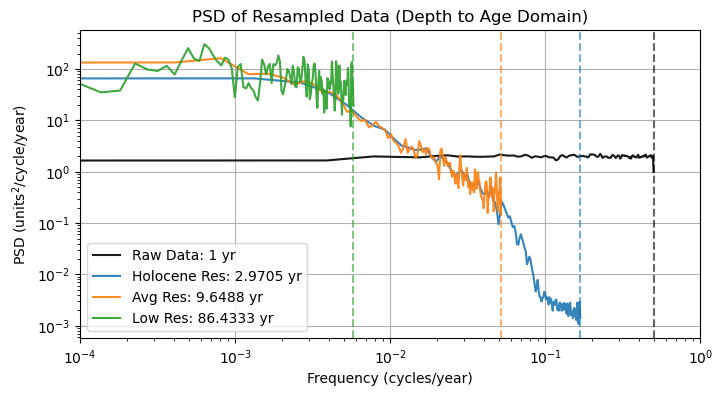

In [13]:
# produce spectra of resampled data
fig, ax = plt.subplots(figsize=(8, 4))

for i, (data, age, label) in enumerate(zip([y, holocene_y, avg_y, low_y], [x, holocene_age, avg_age, low_age], 
                           ['Raw Data: 1 yr', f'Holocene Res: {holocene_res:.4f} yr', f'Avg Res: {avg_res:.4f} yr', f'Low Res: {low_res:.4f} yr'])):
    res = np.mean(np.diff(age)) # downsampling resolution (years)
    fs = 1 / res  # sampling frequency (samples/yr)
    if i == 0:
        color = 'black'
    else:
        color = f'C{i-1}'

    freqw, psdw = welch(data, fs=fs) # frequency units: cycles/yr, output value: psd

    ax.loglog(freqw, psdw, color=color, alpha=0.9, label=label) # plot welch
    ax.axvline(x=1/res/2, color=color, alpha=0.6, linestyle='--', label=f'')

ax.set_xlabel('Frequency (cycles/year)')
ax.set_ylabel(r'PSD (units$^2$/cycle/year)')
ax.set_title(f'PSD of Resampled Data (Depth to Age Domain)')
ax.grid()
ax.legend()
ax.set_xlim(1e-4, 1e0)